In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ustawienia wykresów
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 18

In [2]:
# -----------------------------------------------------------------------------
# 1. ZAŁADOWANIE DANYCH
# -----------------------------------------------------------------------------

iris = load_iris()
X = iris.data                    # 150 próbek × 4 cechy
y = iris.target                  # 3 gatunki (0, 1, 2)
nazwy_cech = ['Długość działki', 'Szerokość działki',
              'Długość płatka', 'Szerokość płatka']
nazwy_gatunkow = ['Setosa', 'Versicolor', 'Virginica']

print(f"\nWymiary danych: {X.shape[0]} próbek × {X.shape[1]} cechy")
print(f"Cechy: {nazwy_cech}")
print(f"Gatunki: {nazwy_gatunkow}")


Wymiary danych: 150 próbek × 4 cechy
Cechy: ['Długość działki', 'Szerokość działki', 'Długość płatka', 'Szerokość płatka']
Gatunki: ['Setosa', 'Versicolor', 'Virginica']


In [3]:
print(f"\nWymiary danych: {X.shape[0]} próbek × {X.shape[1]} cechy")
print(f"Cechy: {nazwy_cech}")
print(f"Gatunki: {nazwy_gatunkow}")


Wymiary danych: 150 próbek × 4 cechy
Cechy: ['Długość działki', 'Szerokość działki', 'Długość płatka', 'Szerokość płatka']
Gatunki: ['Setosa', 'Versicolor', 'Virginica']


In [4]:
# -----------------------------------------------------------------------------
# 2. STANDARYZACJA DANYCH (WAŻNE!)
# -----------------------------------------------------------------------------
# PCA jest wrażliwe na skalę - zmienne o większej wariancji dominują!
# Dlatego ZAWSZE standaryzujemy dane przed PCA

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("\n" + "-" * 60)
print("STANDARYZACJA (mean=0, std=1)")
print("-" * 60)
print(f"Przed: średnie = {X.mean(axis=0).round(2)}")
print(f"Po:    średnie = {X_std.mean(axis=0).round(2)}")



------------------------------------------------------------
STANDARYZACJA (mean=0, std=1)
------------------------------------------------------------
Przed: średnie = [5.84 3.06 3.76 1.2 ]
Po:    średnie = [-0. -0. -0. -0.]


In [5]:
# -----------------------------------------------------------------------------
# 3. WYKONANIE PCA
# -----------------------------------------------------------------------------

pca = PCA()  # Wszystkie składowe (domyślnie n_components = min(n_samples, n_features))
X_pca = pca.fit_transform(X_std)

print("\n" + "-" * 60)
print("WYNIKI PCA")
print("-" * 60)

# Wartości własne (eigenvalues) - pokazują "siłę" każdej składowej
print("\nWartości własne (eigenvalues):")
for i, ev in enumerate(pca.explained_variance_):
    print(f"  PC{i+1}: {ev:.3f}")

# Procent wyjaśnionej wariancji - kluczowa metryka!
print("\nWyjaśniona wariancja (%):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")

# Skumulowana wariancja - ile łącznie wyjaśniają składowe
print(f"\nSkumulowana wariancja:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cs in enumerate(cumsum):
    print(f"  PC1-PC{i+1}: {cs*100:.1f}%")

print("\n→ Wniosek: PC1 + PC2 wyjaśniają", f"{cumsum[1]*100:.1f}% wariancji!")
print("→ Można zredukować 4D → 2D z minimalną stratą informacji")


------------------------------------------------------------
WYNIKI PCA
------------------------------------------------------------

Wartości własne (eigenvalues):
  PC1: 2.938
  PC2: 0.920
  PC3: 0.148
  PC4: 0.021

Wyjaśniona wariancja (%):
  PC1: 73.0%
  PC2: 22.9%
  PC3: 3.7%
  PC4: 0.5%

Skumulowana wariancja:
  PC1-PC1: 73.0%
  PC1-PC2: 95.8%
  PC1-PC3: 99.5%
  PC1-PC4: 100.0%

→ Wniosek: PC1 + PC2 wyjaśniają 95.8% wariancji!
→ Można zredukować 4D → 2D z minimalną stratą informacji


In [6]:
# -----------------------------------------------------------------------------
# 4. ŁADUNKI (LOADINGS) - interpretacja składowych
# -----------------------------------------------------------------------------
print("\n" + "-" * 60)
print("ŁADUNKI SKŁADOWYCH (LOADINGS)")
print("-" * 60)
print("\nJak oryginalne cechy wpływają na główne składowe:\n")
print(f"{'Cecha':<20} {'PC1':>8} {'PC2':>8} {'PC3':>8} {'PC4':>8}")
print("-" * 50)
for i, nazwa in enumerate(nazwy_cech):
    loadings = pca.components_[:, i]
    print(f"{nazwa:<20} {loadings[0]:>8.3f} {loadings[1]:>8.3f} {loadings[2]:>8.3f} {loadings[3]:>8.3f}")

print("\n→ PC1: głównie długość i szerokość płatka (rozmiar płatka)")
print("→ PC2: głównie szerokość działki")


------------------------------------------------------------
ŁADUNKI SKŁADOWYCH (LOADINGS)
------------------------------------------------------------

Jak oryginalne cechy wpływają na główne składowe:

Cecha                     PC1      PC2      PC3      PC4
--------------------------------------------------
Długość działki         0.521    0.377    0.720   -0.261
Szerokość działki      -0.269    0.923   -0.244    0.124
Długość płatka          0.580    0.024   -0.142    0.801
Szerokość płatka        0.565    0.067   -0.634   -0.524

→ PC1: głównie długość i szerokość płatka (rozmiar płatka)
→ PC2: głównie szerokość działki


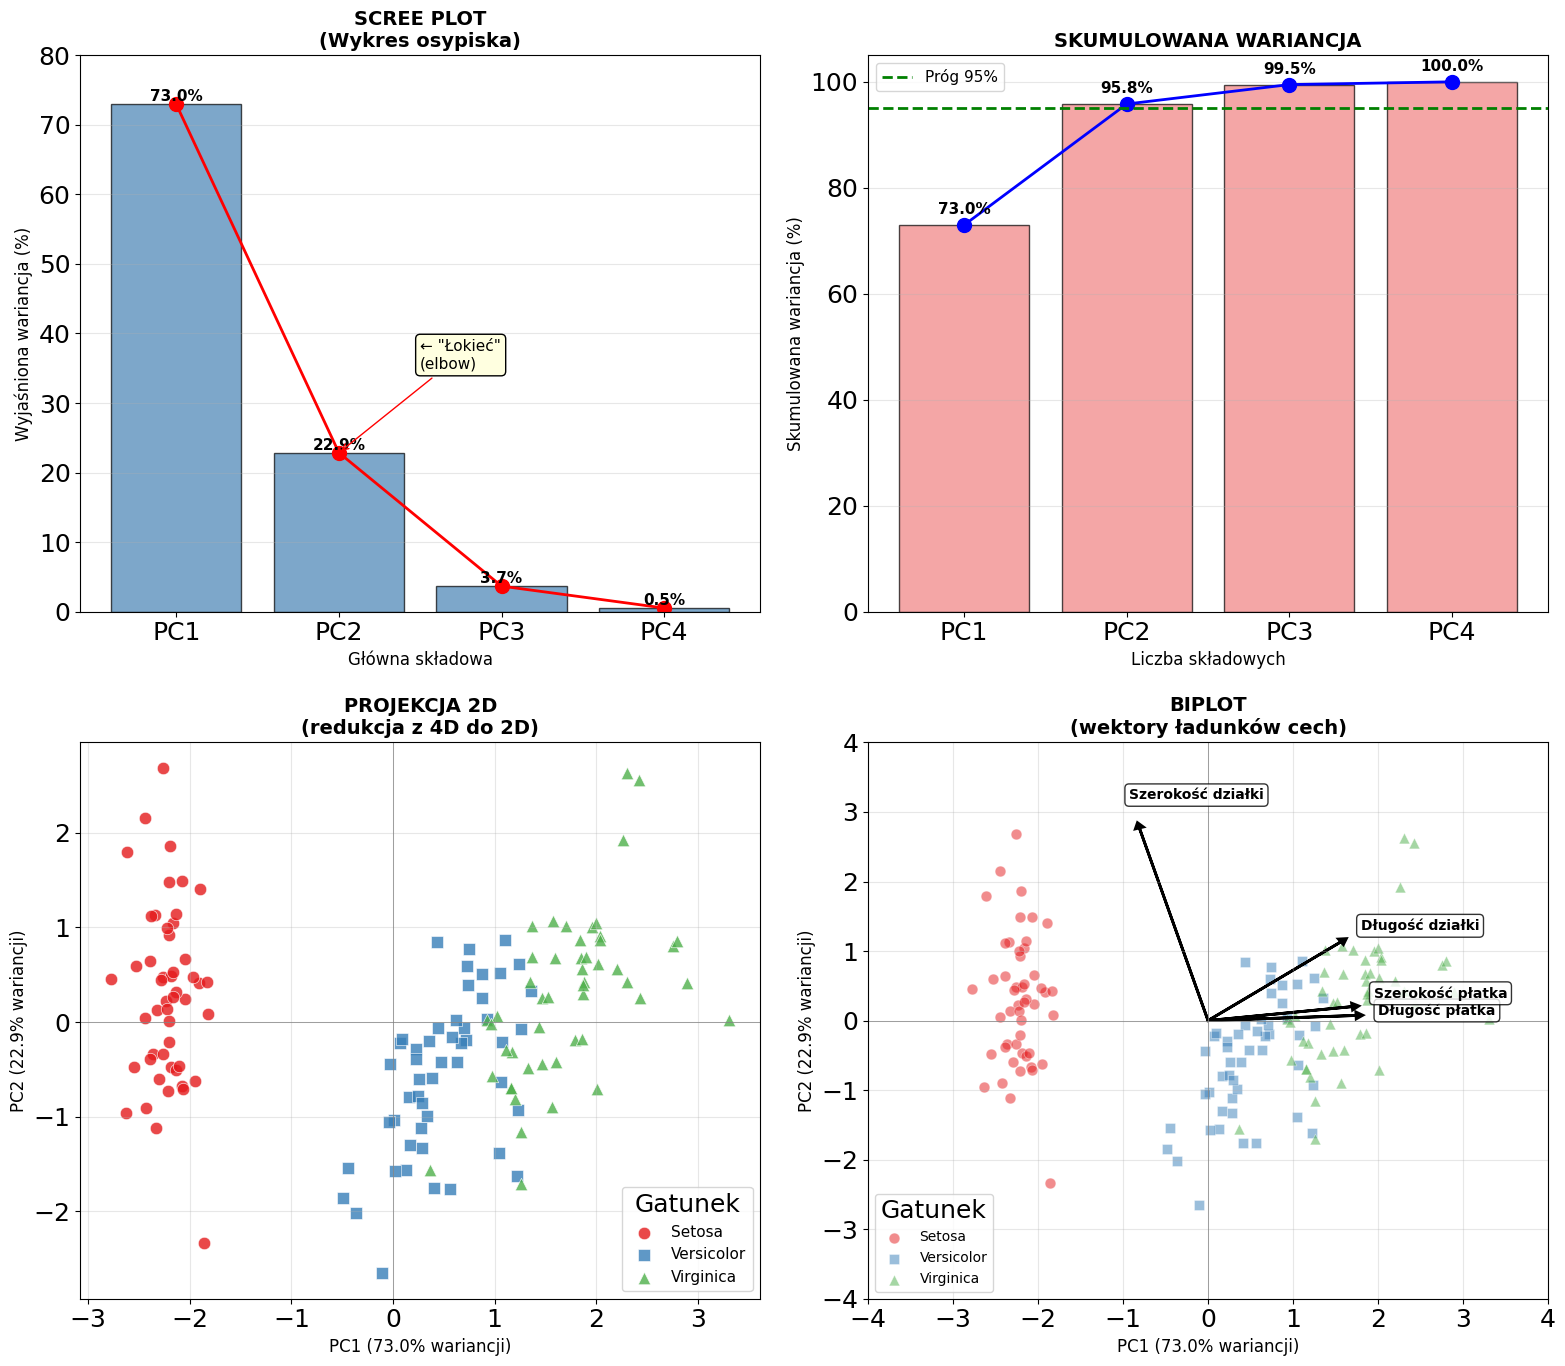

In [7]:
# -----------------------------------------------------------------------------
# 5. WIZUALIZACJE
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- Wykres 1: Scree Plot ---
ax1 = axes[0, 0]
pc_labels = ['PC1', 'PC2', 'PC3', 'PC4']
variance_pct = pca.explained_variance_ratio_ * 100

bars = ax1.bar(pc_labels, variance_pct, color='steelblue', edgecolor='black', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=10, linewidth=2)
ax1.set_ylabel('Wyjaśniona wariancja (%)', fontsize=12)
ax1.set_xlabel('Główna składowa', fontsize=12)
ax1.set_title('SCREE PLOT\n(Wykres osypiska)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 80)

# Adnotacje na słupkach
for bar, pct in zip(bars, variance_pct):
    ax1.annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Zaznaczenie "łokcia"
ax1.annotate('← "Łokieć"\n(elbow)', xy=(1, variance_pct[1]), xytext=(1.5, 35),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.grid(axis='y', alpha=0.3)

# --- Wykres 2: Skumulowana wariancja ---
ax2 = axes[0, 1]
cumulative = np.cumsum(variance_pct)
ax2.bar(pc_labels, cumulative, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.plot(pc_labels, cumulative, 'bo-', markersize=10, linewidth=2)
ax2.axhline(y=95, color='green', linestyle='--', linewidth=2, label='Próg 95%')
ax2.set_ylabel('Skumulowana wariancja (%)', fontsize=12)
ax2.set_xlabel('Liczba składowych', fontsize=12)
ax2.set_title('SKUMULOWANA WARIANCJA', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=11)

for i, pct in enumerate(cumulative):
    ax2.annotate(f'{pct:.1f}%', xy=(i, pct + 2), ha='center', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- Wykres 3: Projekcja 2D (PC1 vs PC2) ---
ax3 = axes[1, 0]
colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers = ['o', 's', '^']

for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_gatunkow, colors, markers)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=kolor, marker=marker, s=80, label=gatunek,
                edgecolor='white', linewidth=0.5, alpha=0.8)

ax3.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax3.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax3.set_title('PROJEKCJA 2D\n(redukcja z 4D do 2D)', fontsize=14, fontweight='bold')
ax3.legend(title='Gatunek', fontsize=11)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# --- Wykres 4: Biplot (wektory cech) ---
ax4 = axes[1, 1]

# Punkty danych
for i, (gatunek, kolor, marker) in enumerate(zip(nazwy_gatunkow, colors, markers)):
    mask = y == i
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=kolor, marker=marker, s=60, label=gatunek,
                edgecolor='white', linewidth=0.5, alpha=0.5)

# Wektory cech (loadings) - pokazują kierunek i siłę wpływu każdej cechy
scale = 3  # skalowanie wektorów dla widoczności
for i, nazwa in enumerate(nazwy_cech):
    if i == 3:
        ax4.arrow(0, 0,
              pca.components_[0, i] * scale,
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax4.text(pca.components_[0, i] * scale * 1.15,
             pca.components_[1, i] * scale * 1.65,
             nazwa, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax4.arrow(0, 0,
              pca.components_[0, i] * scale,
              pca.components_[1, i] * scale,
              head_width=0.1, head_length=0.08, fc='black', ec='black', linewidth=2)
        ax4.text(pca.components_[0, i] * scale * 1.15,
             pca.components_[1, i] * scale * 1.15,
             nazwa, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


ax4.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=12)
ax4.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=12)
ax4.set_title('BIPLOT\n(wektory ładunków cech)', fontsize=14, fontweight='bold')
ax4.legend(title='Gatunek', fontsize=10, loc='lower left')
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax4.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax4.set_xlim(-4, 4)
ax4.set_ylim(-4, 4)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_iris_demo.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# -----------------------------------------------------------------------------
# 6. BONUS: PCA z redukcją do 2 składowych
# -----------------------------------------------------------------------------
print("\n" + "-" * 60)
print("BONUS: Użycie PCA do redukcji wymiarów")
print("-" * 60)

# Możemy też od razu zdefiniować liczbę składowych
pca_2d = PCA(n_components=2)
X_reduced = pca_2d.fit_transform(X_std)

print(f"\nOryginalne wymiary: {X_std.shape}")
print(f"Po redukcji PCA:    {X_reduced.shape}")
print(f"\nZachowana wariancja: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")



------------------------------------------------------------
BONUS: Użycie PCA do redukcji wymiarów
------------------------------------------------------------

Oryginalne wymiary: (150, 4)
Po redukcji PCA:    (150, 2)

Zachowana wariancja: 95.8%


<Axes: >

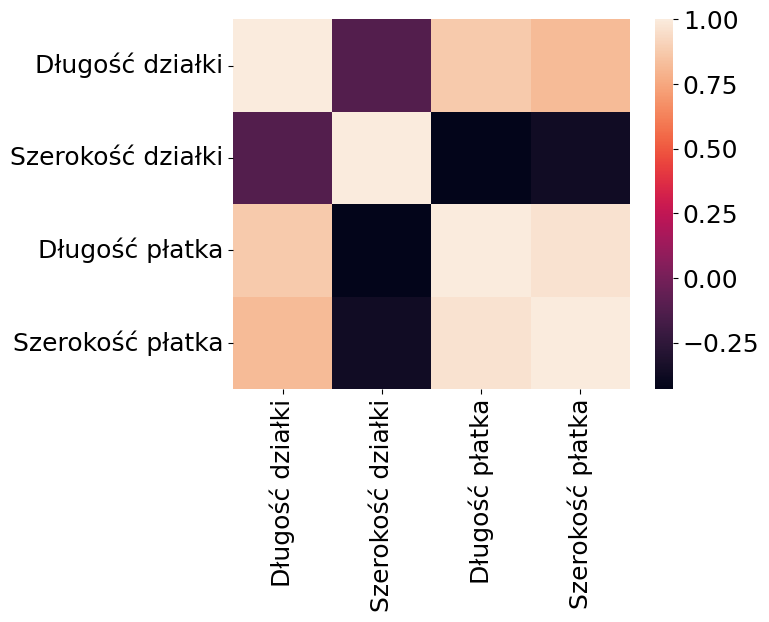

In [9]:
df = pd.DataFrame(X, columns=nazwy_cech)
corr = df.corr()
sns.heatmap(corr)

# Zadania z pliku zadanie_PCA.pdf

3.1 Część 1: Przygotowanie danych

1.1. Załaduj zbiór danych Wine.

1.2. Wyświetl: liczbę próbek i cech, nazwy cech, rozkład klas.

1.3. Przeprowadź standaryzację. Wyjaśnij, dlaczego jest konieczna przed PCA.

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Liczba próbek: {X.shape[0]}, Liczba cech: {X.shape[1]}")
print(f"Nazwy cech: {feature_names}")
unique, counts = np.unique(y, return_counts=True)
print(f"Rozkład klas: {dict(zip(target_names, counts))}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nWyjaśnienie:")
print("Standaryzacja jest konieczna, ponieważ algorytm PCA jest wrażliwy na skalę danych. Szuka on kierunków maksymalnej wariancji.")
print("Bez standaryzacji cechy o dużych zakresach liczbowych całkowicie zdominowałyby wynik, maskując wpływ cech o mniejszych zakresach, ale istotnych dla struktury danych.")

Liczba próbek: 178, Liczba cech: 13
Nazwy cech: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Rozkład klas: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}

Wyjaśnienie:
Standaryzacja jest konieczna, ponieważ algorytm PCA jest wrażliwy na skalę danych. Szuka on kierunków maksymalnej wariancji.
Bez standaryzacji cechy o dużych zakresach liczbowych całkowicie zdominowałyby wynik, maskując wpływ cech o mniejszych zakresach, ale istotnych dla struktury danych.


3.2 Część 2: Wykonanie PCA

2.1. Wykonaj PCA (wszystkie składowe).

2.2. Wyświetl: wartości własne, % wyjaśnionej wariancji, skumulowaną wariancję.

2.3. Ile składowych potrzeba dla >80% wariancji?

In [11]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

eigenvalues = pca.explained_variance_
print("Wartości własne:")
for i, val in enumerate(eigenvalues):
    print(f"PC{i+1}: {val:.4f}")

explained_variance = pca.explained_variance_ratio_ * 100
print("\nProcent wyjaśnionej wariancji:")
for i, val in enumerate(explained_variance):
    print(f"PC{i+1}: {val:.2f}%")

cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100
print("\nSkumulowana wariancja:")
for i, val in enumerate(cumulative_variance):
    print(f"Do PC{i+1}: {val:.2f}%")

components_80 = np.argmax(cumulative_variance > 80) + 1
print(f"\nAby wyjaśnić ponad 80% wariancji, potrzeba {components_80} głównych składowych.")

Wartości własne:
PC1: 4.7324
PC2: 2.5111
PC3: 1.4542
PC4: 0.9242
PC5: 0.8580
PC6: 0.6453
PC7: 0.5541
PC8: 0.3505
PC9: 0.2905
PC10: 0.2523
PC11: 0.2271
PC12: 0.1697
PC13: 0.1040

Procent wyjaśnionej wariancji:
PC1: 36.20%
PC2: 19.21%
PC3: 11.12%
PC4: 7.07%
PC5: 6.56%
PC6: 4.94%
PC7: 4.24%
PC8: 2.68%
PC9: 2.22%
PC10: 1.93%
PC11: 1.74%
PC12: 1.30%
PC13: 0.80%

Skumulowana wariancja:
Do PC1: 36.20%
Do PC2: 55.41%
Do PC3: 66.53%
Do PC4: 73.60%
Do PC5: 80.16%
Do PC6: 85.10%
Do PC7: 89.34%
Do PC8: 92.02%
Do PC9: 94.24%
Do PC10: 96.17%
Do PC11: 97.91%
Do PC12: 99.20%
Do PC13: 100.00%

Aby wyjaśnić ponad 80% wariancji, potrzeba 5 głównych składowych.


3.3 Część 3: Wizualizacja

3.1. Scree Plot zaznacz "łokieć".

3.2. Projekcja 2D (PC1 vs PC2) z kolorami klas.

3.3. Biplot punkty danych + wektory cech.

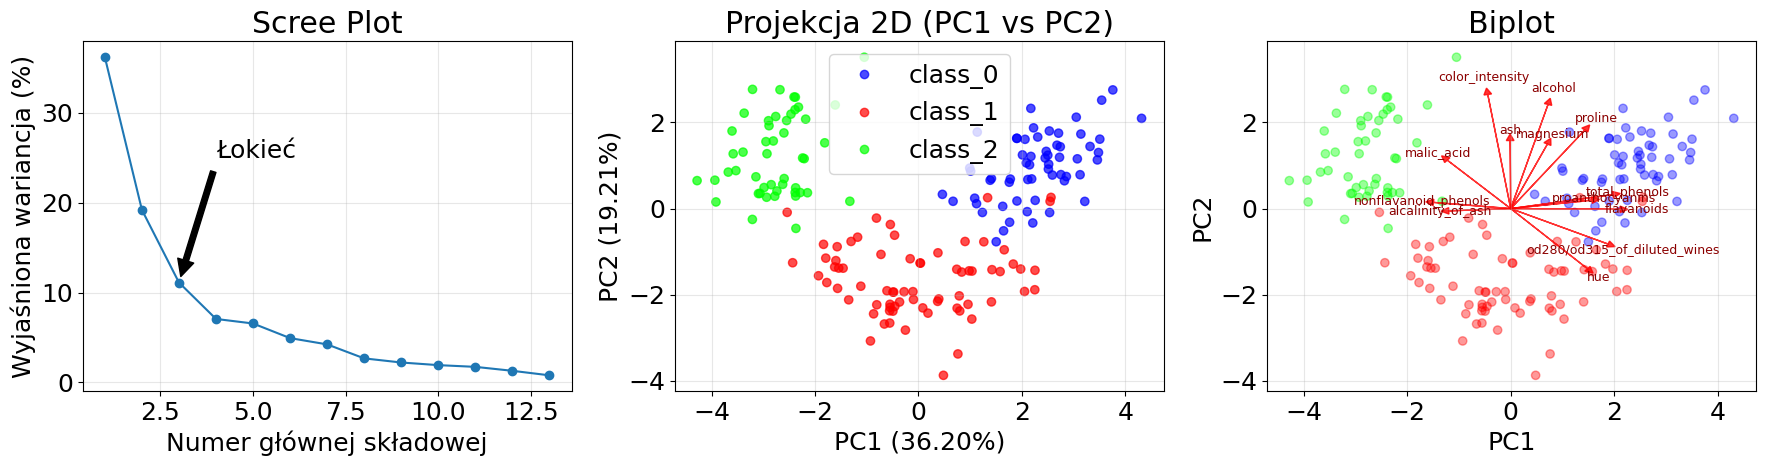

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Numer głównej składowej')
plt.ylabel('Wyjaśniona wariancja (%)')
plt.annotate('Łokieć', xy=(3, explained_variance[2]), xytext=(4, 25),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='brg', alpha=0.7)
plt.title('Projekcja 2D (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='brg', alpha=0.4)
scale = 5
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, pca.components_[0, i] * scale, pca.components_[1, i] * scale,
              head_width=0.15, head_length=0.15, color='red', alpha=0.8)
    plt.text(pca.components_[0, i] * scale * 1.15, pca.components_[1, i] * scale * 1.15,
             feature, color='darkred', ha='center', va='center', fontsize=9)
plt.title('Biplot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

3.4 Część 4: Interpretacja

4.1. Wyświetl ładunki (loadings) dla PC1 i PC2.

4.2. Odpowiedz:

• Które cechy dominują w PC1? Co reprezentuje ta składowa?

• Które cechy dominują w PC2?

• Czy klasy są dobrze separowalne w 2D?

Wyjaśnij różnice która cecha zdominowała analizę bez standaryzacji?

In [13]:
loadings_df = pd.DataFrame(
    pca.components_[:2, :].T,
    columns=['PC1', 'PC2'],
    index=feature_names
)
print("Ładunki (loadings) dla PC1 i PC2:")
print(loadings_df)

print("\n--- Odpowiedzi ---")
print("1. W PC1 dominują cechy: flavanoids, total_phenols, od280/od315_of_diluted_wines (silnie dodatnie) oraz malic_acid, alcalinity_of_ash, nonflavanoid_phenols (silnie ujemne). PC1 reprezentuje głównie ogólną zawartość i jakość związków fenolowych zestawioną z kwasowością wina.")
print("2. W PC2 dominują cechy: color_intensity, ash, magnesium oraz proline (część dodatnia) i hue (ujemna).")
print("3. Tak, klasy wina (0, 1, 2) układają się w wyraźne, odrębne klastry na projekcji 2D, co oznacza, że są bardzo dobrze separowalne za pomocą pierwszych dwóch składowych.")

pca_no_std = PCA()
pca_no_std.fit(X)
print("\n--- Analiza bez standaryzacji ---")
print(pd.Series(pca_no_std.components_[0], index=feature_names).sort_values(ascending=False))
print("\nWyjaśnienie różnicy:")
print("Bez zastosowania standaryzacji analizę PCA całkowicie zdominowała cecha 'proline' (prolina)[cite: 406]. Wynika to z faktu, że jej wartości oscylują w setkach i tysiącach, posiadając największą wariancję ze wszystkich cech, co zaburza naturalną strukturę powiązań między pozostałymi zmiennymi.")

Ładunki (loadings) dla PC1 i PC2:
                                   PC1       PC2
alcohol                       0.144329  0.483652
malic_acid                   -0.245188  0.224931
ash                          -0.002051  0.316069
alcalinity_of_ash            -0.239320 -0.010591
magnesium                     0.141992  0.299634
total_phenols                 0.394661  0.065040
flavanoids                    0.422934 -0.003360
nonflavanoid_phenols         -0.298533  0.028779
proanthocyanins               0.313429  0.039302
color_intensity              -0.088617  0.529996
hue                           0.296715 -0.279235
od280/od315_of_diluted_wines  0.376167 -0.164496
proline                       0.286752  0.364903

--- Odpowiedzi ---
1. W PC1 dominują cechy: flavanoids, total_phenols, od280/od315_of_diluted_wines (silnie dodatnie) oraz malic_acid, alcalinity_of_ash, nonflavanoid_phenols (silnie ujemne). PC1 reprezentuje głównie ogólną zawartość i jakość związków fenolowych zestawioną z kwa